# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy.io
import scipy.ndimage

# Functions

In [2]:
def fspecial(size, sigma):
    ax = np.arange(-size/2 + 0.5, size / 2 + 0.5)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2)/ (2 * sigma ** 2))
    return kernel / kernel.sum()

# Main

In [3]:
showFigs = 1
psfExt = '.mat'
capExt = '.mat'

H = 3648
W = 5472

# Params
gamma_l2 = 1000

# Get capture file
testFile = 'hold_tigerr.mat'
# testFile = 'birds.mat'
testCapDir = './cap/'

frameImg = np.array(h5py.File(testCapDir + testFile, 'r').get('avgCap'))[[0,1,3], : ,:]
frameImg0 = np.rot90(np.fliplr(frameImg[0, :, :]))
frameImg1 = np.rot90(np.fliplr(frameImg[1, :, :]))
frameImg2 = np.rot90(np.fliplr(frameImg[2, :, :]))
Ichs = np.stack([frameImg0, frameImg1, frameImg2], axis = 2)

# print(f"Ichs {Ichs.shape}:\n{Ichs}\n")
outDir = testCapDir

# psf dir
psfFile  = 'psf_d20.mat'
psfDir = './psfs/'

psf = scipy.io.loadmat(psfDir + psfFile)['psf'][:,:,[0,1,3]]

# print(f"psf {psf.shape}:\n{psf}\n")
Ny, Nx, Ch = psf.shape
# print(f"Ny: {Ny}\t Nx: {Nx}\tCh: {Ch}")



In [4]:
# Filter operations
# Fx = lambda x: np.fft.fft2(np.fft.fftshift(x))
# FiltX = lambda H, x: np.real(np.fft.ifftshift(np.fft.ifft2(H * Fx(x))))
Fx = lambda x: np.fft.fft2(np.fft.fftshift(x), axes = (0,1))
FiltX = lambda H, x: np.real(np.fft.ifftshift(np.fft.ifft2(H * Fx(x), axes = (0,1))))
# process bulk PSF
py = 5
px = 5

# padding functions
pad2d = lambda x: np.pad(x,((py, py), (px,px), (0, 0)), 'constant')

# smooth boundary of psf
w_psfCut = 10
kg = fspecial(w_psfCut, 2) 
# print(f"kg {kg.shape}:\n{kg}")
crpSmth = np.zeros([Ny, Nx])
# print(f"1. crpSmth {crpSmth.shape}:\n{crpSmth}")
crpSmth[w_psfCut:Ny - w_psfCut, w_psfCut: Nx - w_psfCut] = 1
# print(f"2. crpSmth {crpSmth.shape}:\n{crpSmth}")
crpSmth = scipy.ndimage.convolve(crpSmth, kg, mode = 'constant')
# print(f"3. crpSmth {crpSmth.shape}:\n{crpSmth}")

psf = psf* np.stack([crpSmth, crpSmth, crpSmth], axis = 2)

# print(f"psf {psf.shape}:\n{psf[:20, :20, 0]}\n")

# Normalized psf with sum val
sms = np.sum(psf, axis = (0, 1), keepdims = True)
# print(f"sms {sms.shape}:\n{sms}\n")
psf = psf / sms
# print(f"psf {psf.shape}:\n{psf[:20, :20, 0]}\n")

psf = psf * sms
# print(f"psf {psf.shape}:\n{psf[:20, :20, 0]}\n")






In [5]:
# Norm and pad
psf = pad2d(psf)
# print(f"psf {psf.shape}:\n{psf[:20, :20, 0]}\n")
# Process input
b = pad2d(Ichs)
bR = b[:, :, 0]
bG = b[:, :, 1]
bB = b[:, :, 2]

# Setup
psfR = psf[:, :, 0]

# Filter in fourier domain
HsR = Fx(psfR)
# print(f"HsR {HsR.shape}:\n{HsR}\n")
HsR_conj = np.conj(HsR)
# print(f"HsR_conj {HsR_conj.shape}:\n{HsR_conj}\n")

# Forward and adjoint of filter
HRfor = lambda x: FiltX(HsR, x)
HRadj = lambda x: FiltX(HsR_conj, x)

# H'H in fourier domain
HtHR = np.abs(HsR * HsR_conj)

# GREEN
psfG = psf[:, :, 1]
HsG = Fx(psfG)
HsG_conj = np.conj(HsG)
HGfor = lambda x: FiltX(HsG, x)
HGadj = lambda x: FiltX(HsG_conj, x)
HtHG = np.abs(HsG*HsG_conj)

# BLUE
psfB = psf[:, :, 2]
HsB = Fx(psfB)
HsB_conj = np.conj(HsB)
HBfor = lambda x: FiltX(HsB, x)
HBadj = lambda x: FiltX(HsB_conj, x)
HtHB = np.abs(HsB * HsB_conj)




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19034794..1.0].


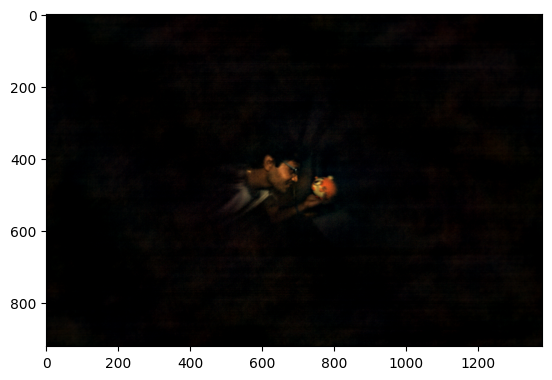

In [6]:
# Reconstruct
xFilt_mult = 1/(HtHR + gamma_l2)
numerator = HRadj(bR)
Rt_nxt = FiltX(xFilt_mult, numerator)

xFilt_mult = 1/(HtHB + gamma_l2)
numerator = HBadj(bB)
Bt_nxt = FiltX(xFilt_mult, numerator)

xFilt_mult = 1/(HtHG + gamma_l2)
numerator = HGadj(bG)
Gt_nxt = FiltX(xFilt_mult, numerator)


# Display
Xt_nxt = np.stack([Rt_nxt, Gt_nxt, Bt_nxt], axis = 2)
maxVal = np.max(Xt_nxt[:])

Xt_nxt = np.single(Xt_nxt/maxVal)
img = plt.imshow(Xt_nxt)


